
========== KNN CLASSIFIER ==========
Accuracy : 0.8
Precision: 0.7979797979797979
Recall   : 0.7979797979797979
F1 Score : 0.7979797979797979

Confusion Matrix:
[[10  0  0]
 [ 0  6  3]
 [ 0  3  8]]

========== DECISION TREE CLASSIFIER ==========
Accuracy : 0.8
Precision: 0.8119658119658119
Recall   : 0.791919191919192
F1 Score : 0.7962962962962963

Confusion Matrix:
[[ 8  2  0]
 [ 0  6  3]
 [ 0  1 10]]


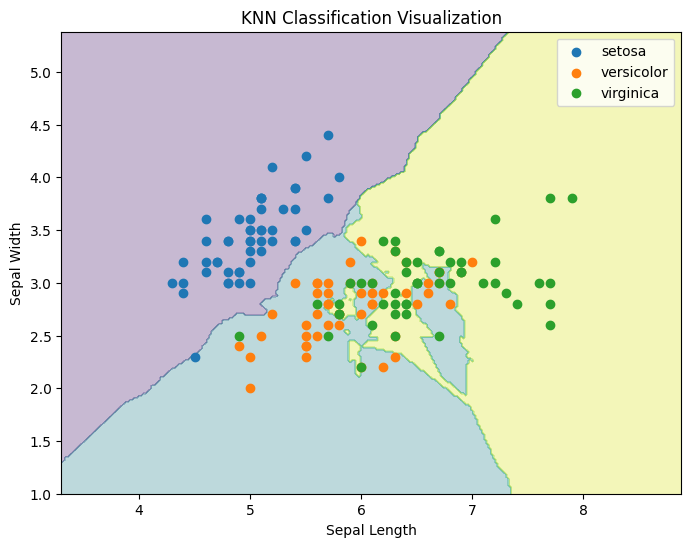

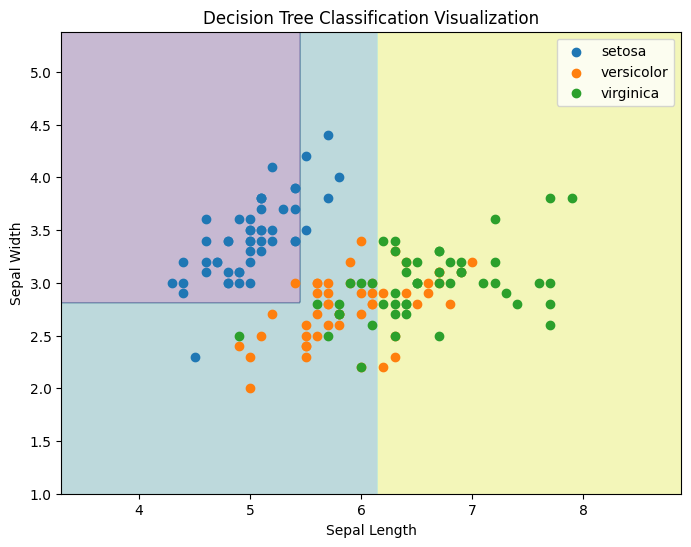

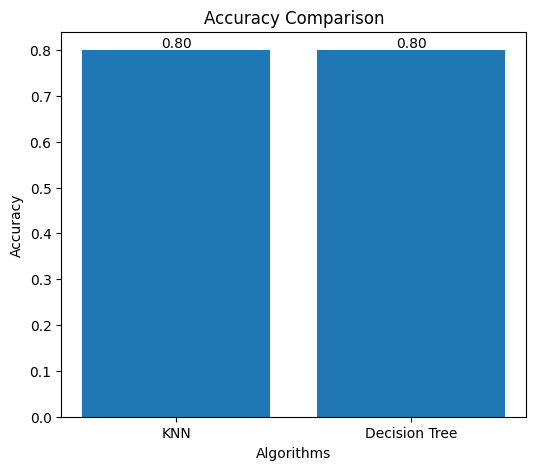

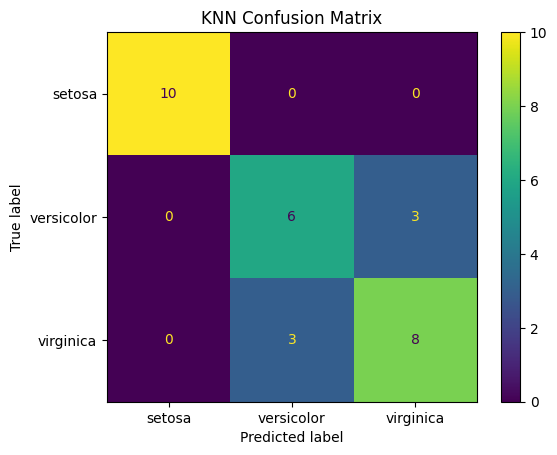

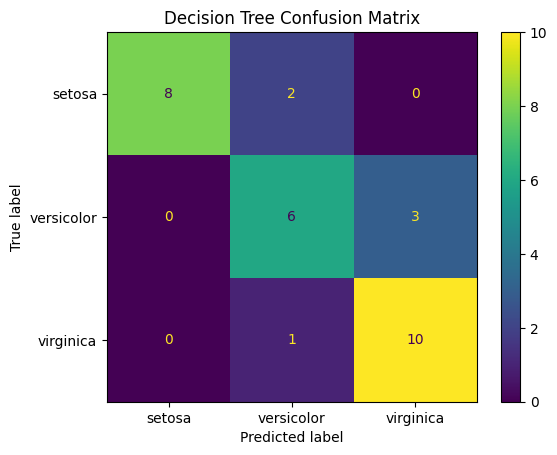

In [1]:
# ---------------------------------------------------
# Install Required Libraries
# ---------------------------------------------------

# pip install scikit-learn
# pip install matplotlib
# pip install pandas
# pip install numpy


# ---------------------------------------------------
# Import Libraries
# ---------------------------------------------------

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Performance Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------------------
# Load Iris Dataset
# ---------------------------------------------------

iris = load_iris()

# Features
X = iris.data

# Target labels
y = iris.target

# Class names
class_names = iris.target_names


# ---------------------------------------------------
# Use only first two features for visualization
# ---------------------------------------------------

# Using:
# Sepal Length
# Sepal Width

X = X[:, :2]


# ---------------------------------------------------
# Split Dataset into Training and Testing
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ===================================================
# KNN CLASSIFICATION
# ===================================================

print("\n========== KNN CLASSIFIER ==========")

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Predict output
knn_pred = knn.predict(X_test)


# ---------------------------------------------------
# KNN Performance Metrics
# ---------------------------------------------------

# Accuracy
knn_accuracy = accuracy_score(y_test, knn_pred)

# Precision
knn_precision = precision_score(
    y_test,
    knn_pred,
    average='macro'
)

# Recall
knn_recall = recall_score(
    y_test,
    knn_pred,
    average='macro'
)

# F1 Score
knn_f1 = f1_score(
    y_test,
    knn_pred,
    average='macro'
)

# Confusion Matrix
knn_cm = confusion_matrix(y_test, knn_pred)


# ---------------------------------------------------
# Print KNN Results
# ---------------------------------------------------

print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

print("\nConfusion Matrix:")
print(knn_cm)


# ===================================================
# DECISION TREE CLASSIFICATION
# ===================================================

print("\n========== DECISION TREE CLASSIFIER ==========")

# Create Decision Tree model
dt = DecisionTreeClassifier(max_depth=2)

# Train model
dt.fit(X_train, y_train)

# Predict output
dt_pred = dt.predict(X_test)


# ---------------------------------------------------
# Decision Tree Performance Metrics
# ---------------------------------------------------

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)

# Precision
dt_precision = precision_score(
    y_test,
    dt_pred,
    average='macro'
)

# Recall
dt_recall = recall_score(
    y_test,
    dt_pred,
    average='macro'
)

# F1 Score
dt_f1 = f1_score(
    y_test,
    dt_pred,
    average='macro'
)

# Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_pred)


# ---------------------------------------------------
# Print Decision Tree Results
# ---------------------------------------------------

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

print("\nConfusion Matrix:")
print(dt_cm)


# ---------------------------------------------------
# Create Mesh Grid for Visualization
# ---------------------------------------------------

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)


# ===================================================
# KNN VISUALIZATION
# ===================================================

# Predict mesh grid values
Z_knn = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z_knn = Z_knn.reshape(xx.shape)

# Create figure
plt.figure(figsize=(8,6))

# Decision boundary
plt.contourf(xx, yy, Z_knn, alpha=0.3)

# Plot data points
for i, name in enumerate(class_names):
    plt.scatter(
        X[y == i, 0],
        X[y == i, 1],
        label=name
    )

# Labels and title
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("KNN Classification Visualization")

# Add legend
plt.legend()

# Show graph
plt.show()


# ===================================================
# DECISION TREE VISUALIZATION
# ===================================================

# Predict mesh grid values
Z_dt = dt.predict(np.c_[xx.ravel(), yy.ravel()])
Z_dt = Z_dt.reshape(xx.shape)

# Create figure
plt.figure(figsize=(8,6))

# Decision boundary
plt.contourf(xx, yy, Z_dt, alpha=0.3)

# Plot data points
for i, name in enumerate(class_names):
    plt.scatter(
        X[y == i, 0],
        X[y == i, 1],
        label=name
    )

# Labels and title
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Decision Tree Classification Visualization")

# Add legend
plt.legend()

# Show graph
plt.show()


# ===================================================
# ACCURACY COMPARISON BAR GRAPH
# ===================================================

algorithms = ['KNN', 'Decision Tree']
accuracies = [knn_accuracy, dt_accuracy]

plt.figure(figsize=(6,5))

bars = plt.bar(algorithms, accuracies)

# Labels
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")

# Add values on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.show()


# ===================================================
# KNN CONFUSION MATRIX VISUALIZATION
# ===================================================

disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=knn_cm,
    display_labels=class_names
)

disp_knn.plot()

plt.title("KNN Confusion Matrix")

plt.show()


# ===================================================
# DECISION TREE CONFUSION MATRIX VISUALIZATION
# ===================================================

disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=class_names
)

disp_dt.plot()

plt.title("Decision Tree Confusion Matrix")

plt.show()